# Predicting `Price category` from the stakeholder dataset

In this notebook, I am trying to answer one concrete question:

**Can I predict the hidden `Price category` from the shipment information that the stakeholder shared with us?**

This is important because the stakeholder explicitly told us that the real paid cost is hidden.  
So I am not trying to predict euros here. I am trying to predict the **encrypted price class** that acts as a proxy for cost.

At this stage, I am treating `Price category` as a **multiclass classification target**.

That means:

- the input is shipment information
- the output is one category such as `B`, `C`, `D`, and so on

I am also being careful with one important point:

Even if some columns look useless to me as a human, they may still be useful to a model.

For example, `Load code` and `Unload code` may look like random internal codes, but if the same lanes appear again and again, the model may still learn meaningful patterns from them.

So in this notebook I will:

1. load the Excel file
2. inspect the data carefully
3. clean obvious issues
4. engineer a few basic features
5. split the data in a time-aware way
6. train a very simple baseline
7. train a stronger classification model
8. evaluate whether the prediction is good enough to be useful

I do **not** want to skip steps here, because if I skip the boring part now, I may trust a wrong model later.

In [1]:
# If I am running this notebook in a fresh environment, I can uncomment this cell.
# I am installing only what I need for this first notebook.

%pip install pandas openpyxl scikit-learn catboost matplotlib seaborn joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Importing the libraries

Before I touch the data, I import the libraries I need.

I am using:

- `pandas` to work with tables
- `numpy` for numerical operations
- `matplotlib` and `seaborn` for quick visuals
- `scikit-learn` for metrics and the baseline model
- `catboost` for the main classifier

I am choosing **CatBoost** for the first real model because this dataset contains many categorical codes such as:

- `Load code`
- `Unload code`
- `Distribution driven by code`
- `Crossdock`

CatBoost is a good fit for this kind of tabular data because it handles categorical features much more naturally than many beginner alternatives.

I also want to be clear about something simple but important:

A model choice is not magic.  
It is just a tool choice.

Right now, my real job is not “find the smartest model.”  
My real job is:

**build one clean and honest pipeline that works from start to finish.**

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    top_k_accuracy_score
)
from sklearn.preprocessing import LabelEncoder
import joblib

from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

## 2. Loading the dataset

Now I load the Excel file.

I already know a few things from earlier inspection:

- the workbook has one relevant sheet
- the sheet name is `Blad2`
- the important columns are:
  - `Shipment`
  - `LAADDATUM`
  - `Load code`
  - `Unload code`
  - `Payweight`
  - `Distribution driven by code`
  - `Price category`
  - `Crossdock`

I also want to keep the file path easy to change.

That may sound obvious, but it matters.

If I hardcode a messy path everywhere, then later I create pain for myself for no reason.

So I keep the path in one variable only.

In [3]:
DATA_PATH = Path("../data/AI purchase cost project (STUDENT DATA).xlsx")
SHEET_NAME = "Blad2"

df = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)

print("Shape:", df.shape)
df.head()

Shape: (780760, 8)


,Shipment,LAADDATUM,Load code,Unload code,Payweight,Distribution driven by code,Price category,Crossdock
0,2261706,2023-01-01,217,535,647.5,19,C,Y
1,2272552,2023-01-02,9,302,700.0,18,B,Y
2,2272495,2023-01-02,66,1855,21000.0,76,E,N
3,2272650,2023-01-02,181,608,700.0,18,B,Y
4,2273247,2023-01-02,21,1010,2100.0,77,C,Y


## 3. First inspection

Before I clean anything, I want to simply look at the data.

This is one of the easiest places to become lazy.

It is tempting to jump directly into model training, but that is exactly how beginner mistakes happen.

So here I check:

- the column names
- the data types
- missing values
- a few summary statistics
- whether the target looks balanced or heavily skewed

This part is not glamorous, but it protects me from building nonsense.

In [4]:
print("Columns:")
for col in df.columns:
    print("-", col)

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isna().sum())

print("\nBasic numeric summary:")
display(df.describe(include="all").transpose())

Columns:
- Shipment
- LAADDATUM
- Load code
- Unload code
- Payweight
- Distribution driven by code
- Price category
- Crossdock

Data types:


Shipment                                int64
LAADDATUM                      datetime64[us]
Load code                               int64
Unload code                             int64
Payweight                             float64
Distribution driven by code             int64
Price category                            str
Crossdock                                 str
dtype: object


Missing values:


Shipment                       0
LAADDATUM                      0
Load code                      0
Unload code                    0
Payweight                      0
Distribution driven by code    0
Price category                 0
Crossdock                      0
dtype: int64


Basic numeric summary:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Shipment,780760.0,NaN,NaN,NaN,2693843.104507,2037431.0,2483030.75,2693782.5,2904459.25,3125933.0,243704.723354
LAADDATUM,780760,NaN,NaN,NaN,2024-07-14 05:06:43.102618,2023-01-01 00:00:00,2023-10-13 00:00:00,2024-07-25 00:00:00,2025-04-15 00:00:00,2025-12-31 00:00:00,NaN
Load code,780760.0,NaN,NaN,NaN,88.371766,1.0,15.0,41.0,80.0,1603.0,150.07646
Unload code,780760.0,NaN,NaN,NaN,1239.264706,1.0,255.0,705.0,1642.0,10317.0,1469.463942
Payweight,780760.0,NaN,NaN,NaN,4824.056245,0.0,700.0,1250.0,4375.0,250000.0,8258.5934
Distribution driven by code,780760.0,NaN,NaN,NaN,474.029694,1.0,19.0,51.0,174.0,4570.0,946.175344
Price category,780760,21,B,332257,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crossdock,780760,2,Y,445358,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Understanding what each column probably means

Before I do feature engineering, I want to write down what I think each column means.

This is not only for me.  
This is also for future me, because future me will forget what I assumed.

My current interpretation is:

- `Shipment`  
  shipment identifier

- `LAADDATUM`  
  loading date

- `Load code`  
  loading location code

- `Unload code`  
  unloading location code

- `Payweight`  
  chargeable or billable weight

- `Distribution driven by code`  
  internal distribution or network code

- `Price category`  
  hidden cost proxy, not a real euro amount

- `Crossdock`  
  whether a crossdock step was involved (`Y` or `N`)

There is one important modeling thought here:

`Shipment` looks like an ID.  
IDs are usually dangerous as features.

Why?

Because an ID often identifies a row, but does not describe a pattern that generalizes.

So I already expect that I will **drop `Shipment` from the feature set** later.

In [5]:
# Quick target inspection
price_counts = df["Price category"].value_counts(dropna=False).sort_values(ascending=False)

print("Number of unique price categories:", df["Price category"].nunique())
display(price_counts.head(20))

Number of unique price categories: 21


Price category
B    332257
C    158268
D     86972
E     49150
G     40997
I     29392
F     28199
H     25655
J     17116
K      5930
L      2441
M      1445
N      1271
O       570
Q       350
P       284
R       198
S       108
V        61
T        52
Name: count, dtype: int64

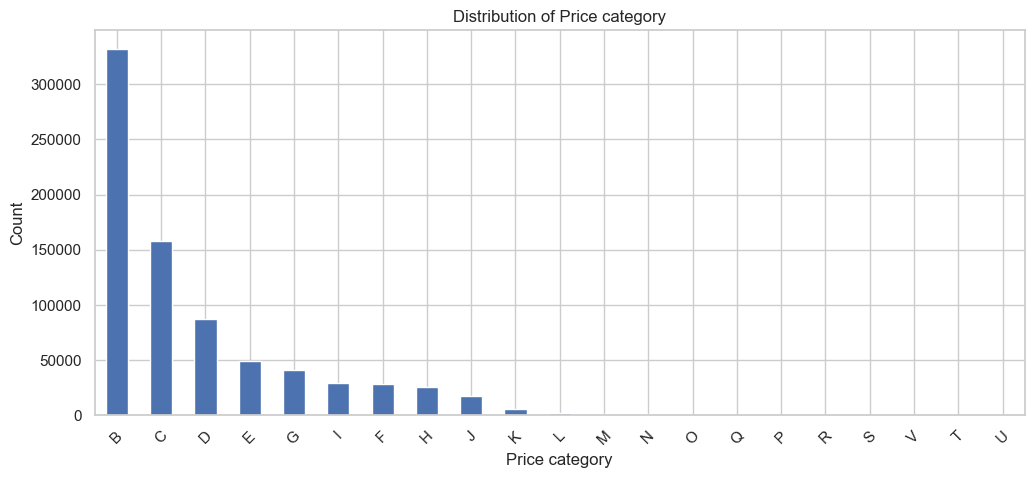

In [6]:
plt.figure(figsize=(12, 5))
price_counts.plot(kind="bar")
plt.title("Distribution of Price category")
plt.xlabel("Price category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## 5. Checking duplicates and weird values

Now I want to check a few practical things:

### 5.1 Repeated shipment IDs
If `Shipment` is supposed to be one shipment number, then I want to know whether the same shipment appears more than once.

That does not automatically mean something is wrong.  
It only tells me whether I should trust it as a unique identifier.

### 5.2 `Payweight`
I also want to inspect `Payweight`, because weight often has:

- zeros
- outliers
- extremely skewed values

And that matters because a model can behave strangely when one numeric column has a huge range.

Duplicated Shipment IDs: 3

Payweight summary:


count    780760.000000
mean       4824.056245
std        8258.593400
min           0.000000
25%         700.000000
50%        1250.000000
75%        4375.000000
max      250000.000000
Name: Payweight, dtype: float64

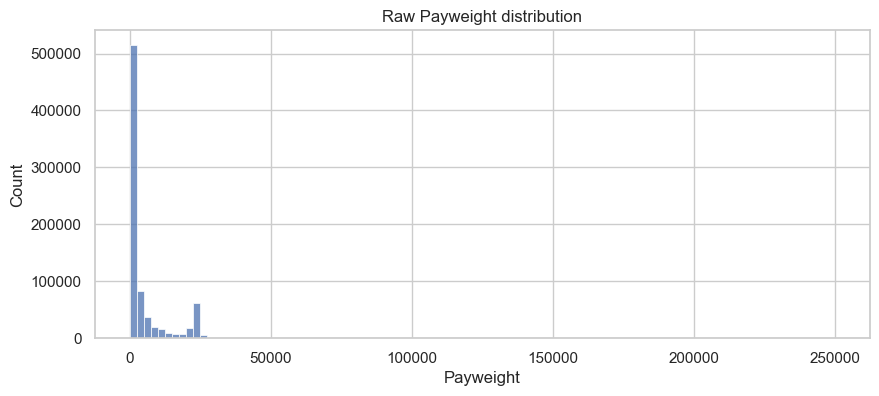

In [7]:
shipment_duplicates = df["Shipment"].duplicated().sum()
print("Duplicated Shipment IDs:", shipment_duplicates)

print("\nPayweight summary:")
display(df["Payweight"].describe())

plt.figure(figsize=(10, 4))
sns.histplot(df["Payweight"], bins=100)
plt.title("Raw Payweight distribution")
plt.xlabel("Payweight")
plt.show()

## 6. Cleaning the date column

Now I clean `LAADDATUM`.

I do not want to assume too much.  
Sometimes Excel dates come in as numbers.  
Sometimes they are already parsed as proper datetimes.

So I check the dtype first, then convert if needed.

After that, I create a few simple date-based features:

- year
- month
- day of week
- week of year
- day of month

Why am I doing this?

Because the raw date itself is often not directly useful to the model, but the **patterns inside the date** are useful.

For example:

- some months may be more expensive than others
- weekdays may behave differently from weekends
- seasonality may exist

This is a very normal and important beginner step in tabular modeling.

In [8]:
# Make a copy so I do not accidentally overwrite the original object mentally
df = df.copy()

if not np.issubdtype(df["LAADDATUM"].dtype, np.datetime64):
    # This branch is a safety net in case the Excel date comes in as a number
    df["LAADDATUM"] = pd.to_datetime(df["LAADDATUM"], origin="1899-12-30", unit="D", errors="coerce")
else:
    df["LAADDATUM"] = pd.to_datetime(df["LAADDATUM"], errors="coerce")

print("Date range:")
print("Min date:", df["LAADDATUM"].min())
print("Max date:", df["LAADDATUM"].max())

df["year"] = df["LAADDATUM"].dt.year
df["month"] = df["LAADDATUM"].dt.month
df["dayofweek"] = df["LAADDATUM"].dt.dayofweek
df["weekofyear"] = df["LAADDATUM"].dt.isocalendar().week.astype(int)
df["dayofmonth"] = df["LAADDATUM"].dt.day

Date range:
Min date: 2023-01-01 00:00:00
Max date: 2025-12-31 00:00:00


## 7. Feature engineering

I am keeping feature engineering simple on purpose.

I do not want to invent ten clever features before I even know whether the basic problem works.

So I will create only a few sensible features:

### 7.1 Route pair
I combine `Load code` and `Unload code` into one route string.

Why?

Because sometimes the pair matters more than each code alone.

For example:

- load code 10 by itself is not enough
- unload code 50 by itself is not enough
- but the route `10 -> 50` may have a stable pricing behavior

### 7.2 Log-transformed weight
If `Payweight` is heavily skewed, then a log transform can make it easier for the model to use the information.

I am not deleting the original weight forever.  
I am only creating an extra version that compresses extreme values.

Mathematically, I use:

$$
\text{payweight\_log1p} = \log(1 + \text{Payweight})
$$

The `+1` is there so that even zero values remain valid.

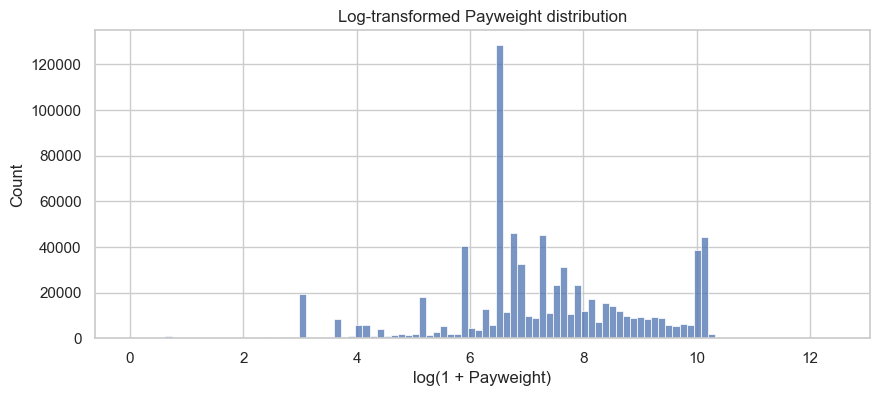

In [9]:
df["route_pair"] = df["Load code"].astype(str) + "_" + df["Unload code"].astype(str)
df["payweight_log1p"] = np.log1p(df["Payweight"])

plt.figure(figsize=(10, 4))
sns.histplot(df["payweight_log1p"], bins=100)
plt.title("Log-transformed Payweight distribution")
plt.xlabel("log(1 + Payweight)")
plt.show()

## 8. Choosing the target and the features

Now I make the modeling choice explicit.

### Target
My target is:

`Price category`

That means this is a **classification problem**.

### Important note
At this stage, I am treating the categories as normal class labels.

I am **not** assuming that the categories are ordinal, because the stakeholder still has to fully confirm the exact business meaning and ordering.

So for now I solve:

**multiclass classification**

not:

**ordinal regression**

### Features
I will start with these features:

- `Load code`
- `Unload code`
- `Distribution driven by code`
- `Crossdock`
- `Payweight`
- `payweight_log1p`
- `year`
- `month`
- `dayofweek`
- `weekofyear`
- `dayofmonth`
- `route_pair`

I will **not** use:
- `Shipment` because it behaves like an ID
- raw `LAADDATUM` because I already extracted the useful time parts from it

In [10]:
target_col = "Price category"

feature_cols = [
    "Load code",
    "Unload code",
    "Distribution driven by code",
    "Crossdock",
    "Payweight",
    "payweight_log1p",
    "year",
    "month",
    "dayofweek",
    "weekofyear",
    "dayofmonth",
    "route_pair",
]

model_df = df[feature_cols + [target_col, "LAADDATUM"]].copy()

print("Model dataframe shape:", model_df.shape)
display(model_df.head())

Model dataframe shape: (780760, 14)


,Load code,Unload code,Distribution driven by code,Crossdock,Payweight,payweight_log1p,year,month,dayofweek,weekofyear,dayofmonth,route_pair,Price category,LAADDATUM
0,217,535,19,Y,647.5,6.474662,2023,1,6,52,1,217_535,C,2023-01-01
1,9,302,18,Y,700.0,6.552508,2023,1,0,1,2,9_302,B,2023-01-02
2,66,1855,76,N,21000.0,9.952325,2023,1,0,1,2,66_1855,E,2023-01-02
3,181,608,18,Y,700.0,6.552508,2023,1,0,1,2,181_608,B,2023-01-02
4,21,1010,77,Y,2100.0,7.650169,2023,1,0,1,2,21_1010,C,2023-01-02


## 9. Time-aware train / validation / test split

This step matters a lot.

I do **not** want to randomly mix all rows from all dates and then pretend I am predicting the future.

That would make the evaluation less honest.

Instead, I split by time:

- older data for training
- middle data for validation
- newest data for testing

This is closer to the real situation.

In real life, the model learns from the past and predicts future shipments.

So I sort by date and split by date ranges, not by random row order.

In [11]:
model_df = model_df.sort_values("LAADDATUM").reset_index(drop=True)

unique_dates = np.array(sorted(model_df["LAADDATUM"].dropna().unique()))

train_cutoff = unique_dates[int(len(unique_dates) * 0.70)]
valid_cutoff = unique_dates[int(len(unique_dates) * 0.85)]

train_df = model_df[model_df["LAADDATUM"] < train_cutoff].copy()
valid_df = model_df[(model_df["LAADDATUM"] >= train_cutoff) & (model_df["LAADDATUM"] < valid_cutoff)].copy()
test_df = model_df[model_df["LAADDATUM"] >= valid_cutoff].copy()

print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)
print("Test shape :", test_df.shape)

print("\nDate ranges")
print("Train:", train_df["LAADDATUM"].min(), "to", train_df["LAADDATUM"].max())
print("Valid:", valid_df["LAADDATUM"].min(), "to", valid_df["LAADDATUM"].max())
print("Test :", test_df["LAADDATUM"].min(), "to", test_df["LAADDATUM"].max())

Train shape: (523840, 14)
Valid shape: (131292, 14)
Test shape : (125628, 14)

Date ranges
Train: 2023-01-01 00:00:00 to 2025-01-30 00:00:00
Valid: 2025-01-31 00:00:00 to 2025-07-12 00:00:00
Test : 2025-07-13 00:00:00 to 2025-12-31 00:00:00


## 10. Optional speed mode

The dataset is large.

That is good for learning, but it can make iteration slower while I am still debugging.

So I create an optional speed mode.

If I only want to test whether the notebook works end-to-end, I can use a smaller sample first.

Later, once the code is stable, I can turn sampling off and train on everything.

This is not cheating.  
This is normal workflow.

First make it work.  
Then make it bigger.

In [12]:
USE_SAMPLE = False
SAMPLE_FRAC = 0.25
RANDOM_STATE = 42

if USE_SAMPLE:
    train_df = train_df.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE)
    valid_df = valid_df.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE)
    test_df = test_df.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE)

print("Train shape after optional sampling:", train_df.shape)
print("Valid shape after optional sampling:", valid_df.shape)
print("Test shape after optional sampling :", test_df.shape)

Train shape after optional sampling: (523840, 14)
Valid shape after optional sampling: (131292, 14)
Test shape after optional sampling : (125628, 14)


## 11. Preparing `X` and `y`

Now I split the data into:

- `X` = input features
- `y` = target labels

I also encode the target labels into integers.

Why am I encoding the target?

Because models usually want the class labels in numeric form, even if the original labels are letters.

This does **not** mean I am changing the business meaning.  
It only means I am giving the model a format it can work with.

I also keep the label encoder, because later I need to convert predictions back into the original categories.

In [13]:
X_train = train_df[feature_cols].copy()
X_valid = valid_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

y_train_raw = train_df[target_col].astype(str).copy()
y_valid_raw = valid_df[target_col].astype(str).copy()
y_test_raw = test_df[target_col].astype(str).copy()

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_valid = label_encoder.transform(y_valid_raw)
y_test = label_encoder.transform(y_test_raw)

class_names = label_encoder.classes_

print("Classes learned by the label encoder:")
print(class_names)
print("\nNumber of classes:", len(class_names))

Classes learned by the label encoder:
['B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S'
 'T' 'U' 'V']

Number of classes: 21


## 12. Marking categorical columns for CatBoost

CatBoost needs to know which columns should be treated as categorical.

This is an important step.

Just because a value is stored as a number does **not** mean it should be treated as a true numeric quantity.

For example:

- `Load code = 10`
- `Load code = 11`

does **not** mean code 11 is “slightly larger” or “slightly more” than code 10 in a meaningful business sense.

These are labels, not measurements.

So I tell the model which columns are categories.

In [14]:
cat_cols = [
    "Load code",
    "Unload code",
    "Distribution driven by code",
    "Crossdock",
    "route_pair",
]

# Convert categorical columns to string so their "code" nature is explicit
for col in cat_cols:
    X_train[col] = X_train[col].astype(str)
    X_valid[col] = X_valid[col].astype(str)
    X_test[col] = X_test[col].astype(str)

print("Categorical columns:", cat_cols)

Categorical columns: ['Load code', 'Unload code', 'Distribution driven by code', 'Crossdock', 'route_pair']


## 13. Building the baseline model

Before I train the stronger model, I need a baseline.

This is a very important beginner habit.

A baseline answers this question:

**Is my “smart” model actually smart, or is it barely better than a stupid guess?**

So I start with a `DummyClassifier`.

This model does not learn real patterns.  
It simply predicts the most common class.

If my real model cannot beat this baseline clearly, then something is wrong.

In [15]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train[["Payweight"]], y_train)  # a dummy model still needs some X input shape

dummy_valid_pred = dummy.predict(X_valid[["Payweight"]])
dummy_test_pred = dummy.predict(X_test[["Payweight"]])

print("Dummy validation accuracy:", accuracy_score(y_valid, dummy_valid_pred))
print("Dummy validation balanced accuracy:", balanced_accuracy_score(y_valid, dummy_valid_pred))

print("Dummy test accuracy:", accuracy_score(y_test, dummy_test_pred))
print("Dummy test balanced accuracy:", balanced_accuracy_score(y_test, dummy_test_pred))

Dummy validation accuracy: 0.4261569631051397
Dummy validation balanced accuracy: 0.05
Dummy test accuracy: 0.4130209825835005
Dummy test balanced accuracy: 0.047619047619047616


## 14. Training the first real model

Now I train the real classifier.

I am using `CatBoostClassifier` with:

- multiclass loss
- automatic balancing for class imbalance
- early stopping on the validation set

### Why early stopping?
Because I do not want the model to keep learning forever if the validation performance stops improving.

That would increase the risk of overfitting.

### Why class balancing?
Because the price categories are not equally frequent.

If one category appears much more often than the others, then the model may become lazy and over-predict the large class.

Automatic balancing helps reduce that problem.

In [16]:
catboost_model = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="Accuracy",
    iterations=500,
    learning_rate=0.1,
    depth=6,
    random_seed=42,
    auto_class_weights="Balanced",
    early_stopping_rounds=50,
    verbose=100
)

catboost_model.fit(
    X_train,
    y_train,
    cat_features=cat_cols,
    eval_set=(X_valid, y_valid),
    use_best_model=True
)

0:	learn: 0.1567680	test: 0.1300531	best: 0.1300531 (0)	total: 11.1s	remaining: 1h 32m 13s
100:	learn: 0.4617801	test: 0.2942811	best: 0.2956829 (97)	total: 12m 45s	remaining: 50m 23s
200:	learn: 0.5860090	test: 0.3208673	best: 0.3221507 (194)	total: 26m 55s	remaining: 40m 2s
300:	learn: 0.6535678	test: 0.3445439	best: 0.3451522 (297)	total: 42m 7s	remaining: 27m 50s


KeyboardInterrupt: 

## 15. Evaluating the model

Now I evaluate the model on both validation and test data.

I care about several things:

### Accuracy
This tells me the percentage of exact predictions that are correct.

### Balanced accuracy
This is useful when classes are imbalanced.

It asks a fairer question:

**Is the model doing reasonably well across all classes, not only the biggest one?**

### Top-3 accuracy
This is especially interesting for this business case.

Why?

Because even if the model’s first guess is wrong, it may still place the true category inside its top 3 guesses.

That can still be useful in decision support.

For example, if the app later says:

- most likely category = C
- second likely = B
- third likely = D

that is already more informative than a blind guess.

In [ ]:
valid_pred = catboost_model.predict(X_valid)
test_pred = catboost_model.predict(X_test)

valid_pred = np.array(valid_pred).astype(int).reshape(-1)
test_pred = np.array(test_pred).astype(int).reshape(-1)

valid_proba = catboost_model.predict_proba(X_valid)
test_proba = catboost_model.predict_proba(X_test)

print("Validation accuracy:", accuracy_score(y_valid, valid_pred))
print("Validation balanced accuracy:", balanced_accuracy_score(y_valid, valid_pred))
print("Validation top-3 accuracy:", top_k_accuracy_score(y_valid, valid_proba, k=3, labels=np.arange(len(class_names))))

print("\nTest accuracy:", accuracy_score(y_test, test_pred))
print("Test balanced accuracy:", balanced_accuracy_score(y_test, test_pred))
print("Test top-3 accuracy:", top_k_accuracy_score(y_test, test_proba, k=3, labels=np.arange(len(class_names))))

## 16. Reading the classification report

The classification report helps me see more than one number.

It shows, for each class:

- precision
- recall
- f1-score
- support

I do not want to skip these words, so I will say what they mean simply.

### Precision
When the model predicts a class, how often is it correct?

### Recall
Out of all the real rows that belong to a class, how many did the model successfully find?

### F1-score
A combined score that balances precision and recall.

### Support
How many examples of that class exist in the evaluated data.

For a stakeholder project, this matters because I do not want a model that only performs well on the biggest category and fails badly on the smaller ones.

In [ ]:
print("Validation classification report:")
print(classification_report(y_valid, valid_pred, target_names=class_names))

print("\nTest classification report:")
print(classification_report(y_test, test_pred, target_names=class_names))

## 17. Looking at the confusion matrix

A confusion matrix answers a simple but powerful question:

**When the model makes mistakes, which classes does it confuse with each other?**

This matters because not all mistakes are equally bad.

If the model confuses nearby-looking price categories, that may be more understandable.

If it makes completely random jumps, that is more worrying.

Because the full matrix may be large, I am still plotting it so I can visually inspect the behavior.

In [ ]:
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap="Greys")
plt.title("Confusion Matrix on Test Set")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.show()

## 18. Feature importance

Now I want to know which features the model relied on the most.

This does **not** mean the model understands causality.

It only means:

**Which inputs were most useful to the model while building its decisions?**

This is still valuable, because it helps me answer questions like:

- Is `Payweight` important?
- Is the route itself important?
- Does `Crossdock` matter?
- Are date features meaningful?

If a feature I expected to matter has almost no importance, that is something I want to know.

In [ ]:
importances = catboost_model.get_feature_importance()
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": importances
}).sort_values("importance", ascending=False)

display(importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x="importance", y="feature")
plt.title("CatBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 19. Turning predicted numbers back into business labels

The model internally works with encoded integer classes.

Humans do not want that.

So now I translate the predictions back into the original `Price category` labels.

This is one of those tiny steps that is easy to forget, but it matters because the frontend and the group need outputs in the real business language.

In [ ]:
test_pred_labels = label_encoder.inverse_transform(test_pred)
test_true_labels = label_encoder.inverse_transform(y_test)

prediction_preview = X_test.head(20).copy()
prediction_preview["true_price_category"] = test_true_labels[:20]
prediction_preview["predicted_price_category"] = test_pred_labels[:20]

display(prediction_preview)

## 20. Example prediction for one shipment-like row

Now I want to simulate what later happens in the application.

The frontend will eventually send one row of input values.

So here I test the model on one example row and look at:

- predicted class
- confidence distribution over classes
- top 3 most likely categories

This is useful because a business app usually should not return only one cold answer.  
It should also show how certain the model is.

In [ ]:
example_row = X_test.head(1).copy()

example_pred = catboost_model.predict(example_row)
example_pred = np.array(example_pred).astype(int).reshape(-1)

example_proba = catboost_model.predict_proba(example_row)[0]

top3_idx = np.argsort(example_proba)[-3:][::-1]
top3_labels = label_encoder.inverse_transform(top3_idx)
top3_scores = example_proba[top3_idx]

print("Predicted category:", label_encoder.inverse_transform(example_pred)[0])

print("\nTop 3 most likely categories:")
for label, score in zip(top3_labels, top3_scores):
    print(f"{label}: {score:.4f}")

## 21. Saving the model and the metadata

If this notebook produces a useful model, I do not want to retrain it every single time from scratch just to test the app.

So I save:

- the trained model
- the label encoder
- the feature list
- the categorical column list

This is the bridge between modeling work and application work.

The backend can later load this file and use it for predictions.

In [ ]:
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

artifact = {
    "model": catboost_model,
    "label_encoder": label_encoder,
    "feature_cols": feature_cols,
    "cat_cols": cat_cols,
}

joblib.dump(artifact, MODEL_DIR / "price_category_catboost.joblib")
print("Model artifact saved.")

## 22. Final interpretation

At the end of this notebook, I want to be honest with myself about what I achieved.

If the model performs well, then I can say:

- the shared shipment fields contain enough signal to predict the hidden `Price category`
- the project can move forward as a classification-based decision support prototype
- the frontend can later use the model’s predictions and probabilities

If the model performs poorly, then I should **not** hide that fact.

In that case, the correct conclusion is probably one of these:

- the available features are too weak
- the target is noisy
- the hidden business logic behind `Price category` is more complex than the shared columns suggest
- more stakeholder information is needed

That is still a useful result.

A weak model is not a failure if it teaches me that the data is not enough.

For now, my goal is simple:

**build the first honest notebook, measure the result properly, and use that result to decide the next step.**

In [ ]:
summary = {
    "dummy_test_accuracy": accuracy_score(y_test, dummy_test_pred),
    "dummy_test_balanced_accuracy": balanced_accuracy_score(y_test, dummy_test_pred),
    "model_test_accuracy": accuracy_score(y_test, test_pred),
    "model_test_balanced_accuracy": balanced_accuracy_score(y_test, test_pred),
    "model_test_top3_accuracy": top_k_accuracy_score(y_test, test_proba, k=3, labels=np.arange(len(class_names))),
}

summary